In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
df = pd.read_csv("data/AIML Dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
df.shape

(6362620, 11)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [10]:
round(df["isFraud"].value_counts(normalize=True) * 100, 4)

isFraud
0    99.8709
1     0.1291
Name: proportion, dtype: float64

In [11]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [12]:
pd.crosstab(
    df["type"],
    df["isFraud"]
)

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [13]:
round(
    pd.crosstab(
        df["type"],
        df["isFraud"],
        normalize="index"
    ) * 100,
    4
)

isFraud,0,1
type,,
CASH_IN,100.0000,0.0000
CASH_OUT,99.8160,0.1840
DEBIT,100.0000,0.0000
PAYMENT,100.0000,0.0000
TRANSFER,99.2312,0.7688


In [14]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


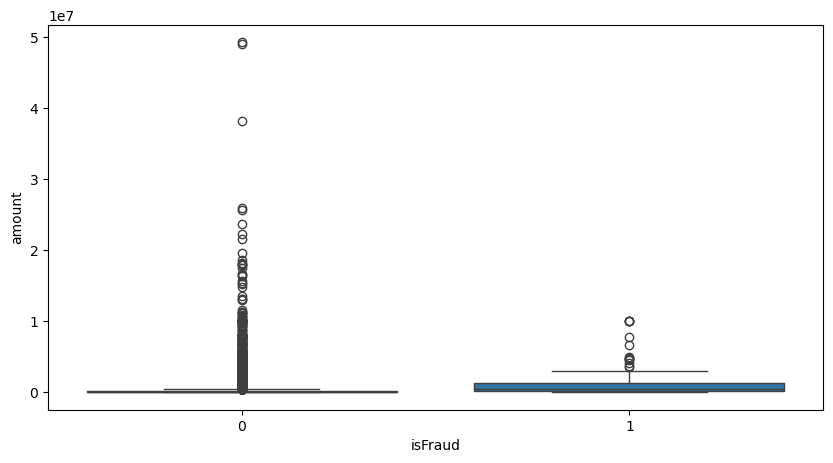

In [15]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df.sample(100000),
    x="isFraud",
    y="amount"
)

plt.show()

In [16]:
df.groupby("isFraud")[
    [
        "oldbalanceOrg",
        "newbalanceOrig",
        "oldbalanceDest",
        "newbalanceDest"
    ]
].mean()

,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
isFraud,,,,
0,8.328287e+05,855970.228109,1.101421e+06,1.224926e+06
1,1.649668e+06,192392.631836,5.442496e+05,1.279708e+06


In [17]:
zero_after_transfer = df[
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0)
]

pd.crosstab(
    zero_after_transfer["isFraud"],
    columns="count"
)

col_0,count
isFraud,
0,1512569
1,8012


In [18]:
round(
    zero_after_transfer["isFraud"]
    .value_counts(normalize=True) * 100,
    2
)

isFraud
0    99.47
1     0.53
Name: proportion, dtype: float64

In [19]:
df["type"] = df["type"].astype("category")

df.groupby("type")["amount"].mean()

C:\Users\verma\AppData\Local\Temp\ipykernel_21956\89928616.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("type")["amount"].mean()


type
CASH_IN     168920.242004
CASH_OUT    176273.964346
DEBIT         5483.665314
PAYMENT      13057.604660
TRANSFER    910647.009645
Name: amount, dtype: float64

In [20]:
df.groupby("isFraud")["oldbalanceOrg"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,8.328287e+05,2.887144e+06,0.0,0.00,14069.00,106969.50,43818855.30
1,8213.0,1.649668e+06,3.547719e+06,0.0,125822.44,438983.45,1517771.48,59585040.37


In [21]:
fraud_df = df[df["isFraud"] == 1]

fraud_df["type"].value_counts()

type
CASH_OUT    4116
TRANSFER    4097
CASH_IN        0
DEBIT          0
PAYMENT        0
Name: count, dtype: int64

In [22]:
fraud_df["type"].value_counts(normalize=True) * 100

type
CASH_OUT    50.11567
TRANSFER    49.88433
CASH_IN      0.00000
DEBIT        0.00000
PAYMENT      0.00000
Name: proportion, dtype: float64

In [23]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [24]:
pd.crosstab(
    df["isFlaggedFraud"],
    df["isFraud"]
)

isFraud,0,1
isFlaggedFraud,,
0,6354407,8197
1,0,16


In [25]:
import numpy as np

df["balance_diff_orig"] = (
    df["oldbalanceOrg"] -
    df["newbalanceOrig"]
)

df["balance_diff_dest"] = (
    df["newbalanceDest"] -
    df["oldbalanceDest"]
)

df["hour"] = df["step"] % 24

df["day"] = df["step"] // 24

df["is_account_emptied"] = (
    (df["oldbalanceOrg"] > 0) &
    (df["newbalanceOrig"] == 0)
).astype(int)

df["full_balance_transfer"] = (
    df["amount"] ==
    df["oldbalanceOrg"]
).astype(int)

df["amount_balance_ratio"] = (
    df["amount"] /
    (df["oldbalanceOrg"] + 1)
)

df["dest_balance_ratio"] = (
    df["amount"] /
    (df["oldbalanceDest"] + 1)
)

df["sender_balance_missing"] = (
    df["oldbalanceOrg"] == 0
).astype(int)

df["receiver_balance_missing"] = (
    df["oldbalanceDest"] == 0
).astype(int)

df["log_amount"] = np.log1p(df["amount"])

threshold = df["amount"].quantile(0.95)

df["high_amount"] = (
    df["amount"] > threshold
).astype(int)

In [26]:
df.shape

(6362620, 23)

In [27]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_orig,balance_diff_dest,hour,day,is_account_emptied,full_balance_transfer,amount_balance_ratio,dest_balance_ratio,sender_balance_missing,receiver_balance_missing,log_amount,high_amount
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,1,0,0,0,0.057834,9839.640000,0,1,9.194276,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,1,0,0,0,0.087731,1864.280000,0,1,7.531166,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0,1,0,1,1,0.994505,181.000000,0,1,5.204007,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0,1,0,1,1,0.994505,0.008545,0,0,5.204007,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0,1,0,0,0,0.280788,11668.140000,0,1,9.364703,0


In [28]:
X = df.drop(
    [
        "isFraud",
        "nameOrig",
        "nameDest"
    ],
    axis=1
)

y = df["isFraud"]

print(X.shape)
print(y.shape)

(6362620, 20)
(6362620,)


In [29]:
X.columns.tolist()

['step',
 'type',
 'amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest',
 'isFlaggedFraud',
 'balance_diff_orig',
 'balance_diff_dest',
 'hour',
 'day',
 'is_account_emptied',
 'full_balance_transfer',
 'amount_balance_ratio',
 'dest_balance_ratio',
 'sender_balance_missing',
 'receiver_balance_missing',
 'log_amount',
 'high_amount']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5090096, 20)
(1272524, 20)


In [33]:
X.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,balance_diff_orig,balance_diff_dest,hour,day,is_account_emptied,full_balance_transfer,amount_balance_ratio,dest_balance_ratio,sender_balance_missing,receiver_balance_missing,log_amount,high_amount
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0,1,0,0,0,0.057834,9839.640000,0,1,9.194276,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0,1,0,0,0,0.087731,1864.280000,0,1,7.531166,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,0,181.00,0.0,1,0,1,1,0.994505,181.000000,0,1,5.204007,0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,0,181.00,-21182.0,1,0,1,1,0.994505,0.008545,0,0,5.204007,0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0,1,0,0,0,0.280788,11668.140000,0,1,9.364703,0


In [36]:
X.dtypes

step                           int64
type                        category
amount                       float64
oldbalanceOrg                float64
newbalanceOrig               float64
oldbalanceDest               float64
newbalanceDest               float64
isFlaggedFraud                 int64
balance_diff_orig            float64
balance_diff_dest            float64
hour                           int64
day                            int64
is_account_emptied             int32
full_balance_transfer          int32
amount_balance_ratio         float64
dest_balance_ratio           float64
sender_balance_missing         int32
receiver_balance_missing       int32
log_amount                   float64
high_amount                    int32
dtype: object

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = ["type"]

numerical_features = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "isFlaggedFraud",
    "balance_diff_orig",
    "balance_diff_dest",
    "hour",
    "day",
    "is_account_emptied",
    "full_balance_transfer",
    "amount_balance_ratio",
    "dest_balance_ratio",
    "sender_balance_missing",
    "receiver_balance_missing",
    "log_amount",
    "high_amount"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessor Created Successfully")

Preprocessor Created Successfully


In [38]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

print("Pipeline Ready")

Pipeline Ready


In [41]:
X_train.shape

(5090096, 20)

In [ ]:
%%time

lr_pipeline.fit(
    X_train,
    y_train
)

In [42]:
X_sample = X_train.sample(
    n=1000000,
    random_state=42
)

y_sample = y_train.loc[X_sample.index]

print(X_sample.shape)

(1000000, 20)


In [43]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

In [44]:
%%time

lr_pipeline.fit(
    X_sample,
    y_sample
)

CPU times: total: 3.53 s
Wall time: 3.08 s


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['step', 'amount',
                                                   'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'isFlaggedFraud',
                                                   'balance_diff_orig',
                                                   'balance_diff_dest', 'hour',
                                                   'day', 'is_account_emptied',
                                                   'full_balance_transfer',
                                                   'amount_balance_ratio',
                                                   'dest_balance_ratio',
                                                   'sender_balance_missing',
                                                   'receiver_balance_missing',
                                                   'log_amount',
                                                   'high_amount']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [45]:
y_pred = lr_pipeline.predict(X_test)

In [46]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

[[1270530     351]
 [      3    1640]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.82      1.00      0.90      1643

    accuracy                           1.00   1272524
   macro avg       0.91      1.00      0.95   1272524
weighted avg       1.00      1.00      1.00   1272524



In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        )
    )
])

In [48]:
%%time

rf_pipeline.fit(
    X_sample,
    y_sample
)

CPU times: total: 4min
Wall time: 23.2 s


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['step', 'amount',
                                                   'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'isFlaggedFraud',
                                                   'balance_diff_orig',
                                                   'balance_diff_dest', 'hour',
                                                   'day', 'is_account_emptied',
                                                   'full_balance_transfer',
                                                   'amount_balance_ratio',
                                                   'dest_balance_ratio',
                                                   'sender_balance_missing',
                                                   'receiver_balance_missing',
                                                   'log_amount',
                                                   'high_amount']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

In [49]:
y_pred_rf = rf_pipeline.predict(X_test)

In [50]:
print(confusion_matrix(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

[[1270881       0]
 [      4    1639]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



In [51]:
X_sample["isFraud"] = y_sample

In [52]:
X_sample.groupby("isFlaggedFraud")["isFraud"].value_counts()

isFlaggedFraud  isFraud
0               0          998783
                1            1216
1               1               1
Name: count, dtype: int64

In [53]:
X_no_flag = X.drop("isFlaggedFraud", axis=1)

In [54]:
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_no_flag,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [55]:
X_sample2 = X_train2.sample(
    1000000,
    random_state=42
)

y_sample2 = y_train2.loc[X_sample2.index]

In [56]:
"isFlaggedFraud"

'isFlaggedFraud'

In [58]:
numerical_features2 = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "balance_diff_orig",
    "balance_diff_dest",
    "hour",
    "day",
    "is_account_emptied",
    "full_balance_transfer",
    "amount_balance_ratio",
    "dest_balance_ratio",
    "sender_balance_missing",
    "receiver_balance_missing",
    "log_amount",
    "high_amount"
]

In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor2 = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features2
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            ["type"]
        )
    ]
)

In [60]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_pipeline2 = Pipeline([
    ("preprocessor", preprocessor2),
    (
        "model",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        )
    )
])

In [61]:
rf_pipeline2.fit(
    X_sample2,
    y_sample2
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['step', 'amount',
                                                   'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'balance_diff_orig',
                                                   'balance_diff_dest', 'hour',
                                                   'day', 'is_account_emptied',
                                                   'full_balance_transfer',
                                                   'amount_balance_ratio',
                                                   'dest_balance_ratio',
                                                   'sender_balance_missing',
                                                   'receiver_balance_missing',
                                                   'log_amount',
                                                   'high_amount']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

In [62]:
y_pred_rf2 = rf_pipeline2.predict(X_test2)

In [63]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test2, y_pred_rf2))
print(classification_report(y_test2, y_pred_rf2))

[[1270881       0]
 [      4    1639]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



In [64]:
y_train_pred = rf_pipeline2.predict(X_sample2)

print(classification_report(y_sample2, y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    998783
           1       1.00      1.00      1.00      1217

    accuracy                           1.00   1000000
   macro avg       1.00      1.00      1.00   1000000
weighted avg       1.00      1.00      1.00   1000000



In [65]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_pipeline2,
    X_sample2,
    y_sample2,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

print(scores)
print("Mean F1:", scores.mean())

[0.99793814 1.         1.         0.99381443 0.99588477]
Mean F1: 0.9975274701964277


In [66]:
import joblib

joblib.dump(
    rf_pipeline2,
    "fraud_detection_pipeline.pkl"
)

['fraud_detection_pipeline.pkl']

In [67]:
joblib.dump(
    X_no_flag.columns.tolist(),
    "feature_columns.pkl"
)

['feature_columns.pkl']

In [68]:
from sklearn.metrics import roc_auc_score

y_prob = rf_pipeline2.predict_proba(X_test2)[:, 1]

roc_auc = roc_auc_score(y_test2, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9987706554915758
